# Phase 3 Part 1: A Look at the Datasets #

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bandcamp_sales = pd.read_csv("data/1000000-bandcamp-sales.csv")
spotify_artists = pd.read_csv("data/spotify_artists.csv")
spotify_tracks = pd.read_csv("data/spotify-track-features.csv")

# The Datasets #

**1000000-bandcamp-sales:** https://www.kaggle.com/datasets/mathurinache/1000000-bandcamp-sales\
This dataset contains 1,000,000 individual Bandcamp sales transactions between Sept 9, 2020 - Oct 2, 2020. This is relevant to specifically question three of our proposal where we try to understand whether higher Spotify popularity and Bandcamp sales are associated within the specified timeframe. 

**spotify-track-features:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset\
This dataset contains Spotify’s track data, including track/artist meta-data, popularity scores, genres, and audio features. This is relevant to specifically question two of our proposal where we investigate the relationship between audio features such as danceability, tempo, and energy are associated with track popularity on Spotify,

**spotify-artists:** https://developer.spotify.com/documentation/web-api\
This dataset scraped from Spotify's web API via their developer dashboard contains indie and electronic artists' features such as release date frequency of albums, follower counts, and popularity scores. This is relevant to specifically question one of our proposal where we investigate the predictive abilities of Spotify artist attributes on popularity.

Our overarching research question that we aim to answer through these three smaller investigations is as follows:
### *What factors affect the success of indie and electronic musicians across different streaming platforms?* ###

# Data Cleaning #

## 1000000-bandcamp-sales ##

In [3]:
#bandcamp_sales.head()
bandcamp_sales.columns


Index(['_id', 'art_url', 'item_type', 'utc_date', 'country_code',
       'track_album_slug_text', 'country', 'slug_type', 'amount_paid_fmt',
       'item_price', 'item_description', 'art_id', 'url', 'amount_paid',
       'releases', 'artist_name', 'currency', 'album_title', 'amount_paid_usd',
       'package_image_id', 'amount_over_fmt', 'item_slug', 'addl_count'],
      dtype='object')

We first clean by removing columns that are unnecessary to our data analysis. These include:
- `track_album_slug_text`
- `item_type`
- `utc_date`
- `slug_type`
- `art_url`
- `item_description`
- `url`
- `album_title`
- `releases`
- `item_slug`
- `country`
- `country_code`
- `addl_count`
- `amount_paid_fmt`
- `currency`
- `package_image_id`

This leaves us with 6 columns:
- `_id`
- `item_type` * a for digital albums, t for digital tracks, p for physical items
- `item_price` * note that bandcamp has "pay what you want" option so some prices may be 0 while paid amount =/= 0
- `amount_paid`
- `currency`
- `amount_paid_usd`

In [4]:
bandcamp_sales = bandcamp_sales.drop(columns=[
    'track_album_slug_text','utc_date','art_url',
    'item_description','url','album_title','releases',
    'item_slug','country','country_code','addl_count',
    'amount_paid_fmt', 'slug_type', 'package_image_id', 'art_id'
], errors='ignore')

In [5]:
bandcamp_sales.columns
bandcamp_sales.isna().sum()

_id                     0
item_type               0
item_price              0
amount_paid             0
artist_name            10
currency                0
amount_paid_usd         0
amount_over_fmt    880867
dtype: int64

For further cleaning, we shoudl get rid of the na rows in `artist_name` (the only column with na values) as analysis cannot be done if we do not know who the artist even is. Thankfully, there are only 10 missing artists names so this should not impact analysis at all. 

In [6]:
bandcamp_sales = bandcamp_sales.dropna(subset=['artist_name'])
bandcamp_sales.isna().sum()
len(bandcamp_sales) #make sure 10 rows exactly were dropped from the total dataset

999990

## spotify-track-features ## 

In [7]:
spotify_tracks.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

We first clean by removing columns that are unnecessary to our data analysis. These include:
- `Unnamed: 0`
- `album_name`

Due to department database quotas we should limit the dataset to fewer columns. Remove potential cases of multicollinearity and redundancies: 
- `mode` * 1 for major scale and 0 for minor scale
- `key`
- `loudness`
- `speechiness`
- `liveness`
- `instrumentalness`
- `energy`

This leaves us with 11 columns:
- `track_id`
- `artists` 
- `track_name`
- `popularity`
- `duration_ms`
- `explicit`
- `danceability`
- `acousticness`
- `tempo`
- `valence`
- `track_genre`

In [8]:
spotify_tracks = spotify_tracks.drop(columns=[
    'Unnamed: 0', 'album_name', 'mode', 'key', 'loudness', 'speechiness', 'liveness', 'instrumentalness', 'energy', 'time_signature'
], errors='ignore')
spotify_tracks.isna().sum()

track_id        0
artists         1
track_name      1
popularity      0
duration_ms     0
explicit        0
danceability    0
acousticness    0
valence         0
tempo           0
track_genre     0
dtype: int64

Similar to the previous dataset, just remove the row with na values because if we do not know the track name, it is useless to our analysis. 

In [9]:
spotify_tracks = spotify_tracks.dropna(subset=['track_name'])

## spotify-artist ##

In [10]:
spotify_artists.columns

Index(['name', 'spotify_id', 'popularity', 'followers', 'genres',
       'total_releases', 'first_release', 'latest_release', 'years_active',
       'releases_per_year'],
      dtype='object')

I specifically scraped these features from the Spotify web API so no columns will be removed. The columns are: 
- `name`
- `spotify_id`
- `popularity`
- `followers`
- `genres`
- `total_releases`
- `first_release`
- `latest_release`
- `years_active`
- `releases_per_year`

In [11]:
spotify_artists = spotify_artists.dropna(subset=['first_release'])
spotify_artists.isna().sum()
len(spotify_artists)

3231

## Ensuring Consistent Column Names ##

Later on consistent column names will make joining schemas easier. Variables such as artist name, track name, and genre will be renamed across all datasets.

bandcamp:\
`_id` -> `bc_transaction_id`

tracks:\
`artists` -> `artist_name`\
`track_genre` -> `genre_type`

artists:\
`name` -> `artist_name`\
`genres` -> `genre_type`



In [12]:
bandcamp_sales.rename(columns={'_id': 'bc_transaction_id'}, inplace=True)
spotify_tracks.rename(columns={'artists': 'artist_name', 'track_genre': 'genre_type'}, inplace=True)
spotify_artists.rename(columns={'name': 'artist_name', 'genres':'genre_type'}, inplace = True)

bandcamp_sales.columns
spotify_tracks.columns
spotify_artists.columns

Index(['artist_name', 'spotify_id', 'popularity', 'followers', 'genre_type',
       'total_releases', 'first_release', 'latest_release', 'years_active',
       'releases_per_year'],
      dtype='object')

In [13]:
#save cleaned datasets
bandcamp_sales.to_csv('bandcamp_sales_cleaned.csv', index=False)
spotify_tracks.to_csv('spotify_tracks_cleaned.csv', index=False)
spotify_artists.to_csv('spotify_artists_cleaned.csv', index=False)

# Schema Design #
**Entities:** 

Track(**track_id**, track_name, artist_name, popularity, duration_ms, explicit, danceability, acousticness, valence, tempo, genre_type)
- artist_name is a foreign key referring to Artists entity attribute of the same name
- track_name, artist_name must be unique (avoid duplication of same song between the artist)

Artist(**artist_name**, spotify_id, popularity, followers, genre_type, total_releases, first_release, latest_release, years_active, releases_per_year)
- spotify_id must be unique

Sale(**bc_transaction_id**, artist_name, item_type, item_price, amount_paid, currency, amount_paid_usd)
- artist_name is a foreign key referring to Artists entity attribute of the same name
- numeric values price, paid, must be >=0


#### Pip install oracle

In [14]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("\x1b[31m✗ Unexpected error! Please contact course staff\n" +
         "Please include the entire text above and below in your message.")
    raise

Note: you may need to restart the kernel to use updated packages.


## Research Question 1
Which artist-level attributes (such as catalog size, release frequency, and follower count) are most predictive of popularity for indie and electronic artists on Spotify?

In [36]:
import oracledb

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_isaac184", password="a97241418", dsn=dsn)

query = """
SELECT
    artist_name,
    popularity,
    followers,
    total_releases,
    years_active,
    releases_per_year
FROM Artists
WHERE popularity IS NOT NULL
  AND followers IS NOT NULL
  AND total_releases IS NOT NULL
  AND years_active IS NOT NULL
  AND releases_per_year IS NOT NULL
"""

df = pd.read_sql(query, connection)

print(df)
connection.close()

/var/folders/zx/g3r450jd40b4hw_98q43kjzr0000gn/T/ipykernel_18645/1758692527.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


          ARTIST_NAME  POPULARITY  FOLLOWERS  TOTAL_RELEASES  YEARS_ACTIVE  \
0     Yeah Yeah Yeahs          66    1521439              30          21.7   
1             FINNEAS          66    2417052              34           9.2   
2          Lucy Dacus          65     640159              28           9.6   
3           Jim Croce          65    1724404              11          57.3   
4       Pet Shop Boys          70    2318280             114          41.9   
...               ...         ...        ...             ...           ...   
3225         Mc Delux          64     168488            1930           1.5   
3226            Dzeko          54      81597              49          12.3   
3227    Bruno Martini          63     171903             109           9.4   
3228          Cartoon          59     266521              37          10.3   
3229        Cash Cash          57     706932              72          17.8   

      RELEASES_PER_YEAR  
0                  1.38  
1          

In [37]:
artists = df
artists.head()

,ARTIST_NAME,POPULARITY,FOLLOWERS,TOTAL_RELEASES,YEARS_ACTIVE,RELEASES_PER_YEAR
0,Yeah Yeah Yeahs,66,1521439,30,21.7,1.38
1,FINNEAS,66,2417052,34,9.2,3.71
2,Lucy Dacus,65,640159,28,9.6,2.90
3,Jim Croce,65,1724404,11,57.3,0.19
4,Pet Shop Boys,70,2318280,114,41.9,2.72


In [38]:
y = artists['POPULARITY'].to_numpy()
N = len(y)

x1 = artists['FOLLOWERS'].to_numpy()
x2 = artists['TOTAL_RELEASES'].to_numpy()
x3 = artists['YEARS_ACTIVE'].to_numpy()
x4 = artists['RELEASES_PER_YEAR'].to_numpy()

X = np.column_stack([np.ones(N), x1, x2, x3, x4])

beta = np.linalg.solve(X.T @ X, X.T @ y)
y_pred = X @ beta
residuals = y - y_pred

R2 = 1 - np.sum(residuals**2) / np.sum((y - np.mean(y))**2)
R2adj = 1 - (1 - R2) * (N - 1) / (N - 5)

print("Linear model coefficients:", beta)
print("Linear model R2:", R2)
print("Linear model Adjusted R2:", R2adj)

Linear model coefficients: [ 4.66415346e+01  2.52383217e-06  4.48094651e-02  3.22295122e-02
 -6.13130476e-02]
Linear model R2: 0.2486952968410444
Linear model Adjusted R2: 0.24776344604642864


In [39]:
x1_log = np.log1p(artists['FOLLOWERS'].to_numpy())
x2_log = np.log1p(artists['TOTAL_RELEASES'].to_numpy())
x3_log = np.log1p(artists['YEARS_ACTIVE'].to_numpy())
x4_log = np.log1p(artists['RELEASES_PER_YEAR'].to_numpy())

X_log = np.column_stack([np.ones(N), x1_log, x2_log, x3_log, x4_log])

beta_log = np.linalg.solve(X_log.T @ X_log, X_log.T @ y)
y_pred_log = X_log @ beta_log
residuals_log = y - y_pred_log

R2_log = 1 - np.sum(residuals_log**2) / np.sum((y - np.mean(y))**2)
R2adj_log = 1 - (1 - R2_log) * (N - 1) / (N - 5)

print("Log model coefficients:", beta_log)
print("Log model R2:", R2_log)
print("Log model Adjusted R2:", R2adj_log)

Log model coefficients: [-10.55479989   4.71407547  -2.97083382   1.89999999   7.93706184]
Log model R2: 0.6356411119185664
Log model Adjusted R2: 0.6351891939178452


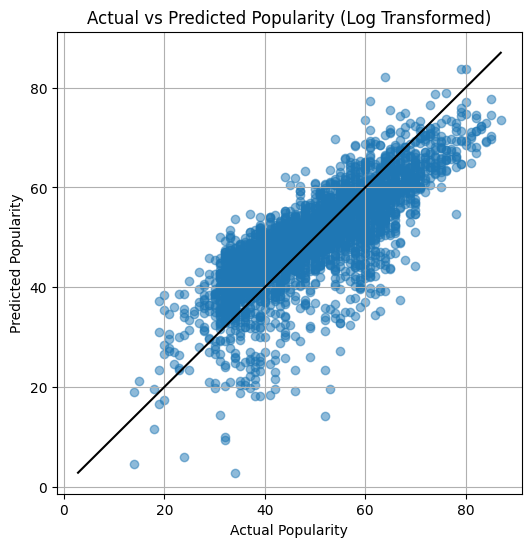

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_log, alpha=0.5)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity (Log Transformed)')
plt.grid(True)

min_val = min(np.min(y), np.min(y_pred_log))
max_val = max(np.max(y), np.max(y_pred_log))
plt.plot([min_val, max_val], [min_val, max_val], color = 'black')
plt.show()

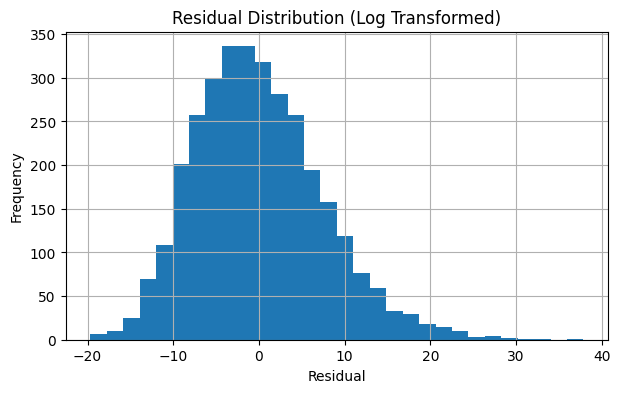

In [41]:
plt.figure(figsize=(7,4))
plt.hist(residuals_log, bins=30)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution (Log Transformed)')
plt.grid(True)
plt.show()

In [42]:
model_summary = pd.DataFrame({
    'Model': ['Linear', 'Log-transformed'],
    'R2': [R2, R2_log],
    'Adjusted R2': [R2adj, R2adj_log]
})

coef_table = pd.DataFrame({
    'Variable': ['Intercept', 'FOLLOWERS', 'TOTAL_RELEASES', 'YEARS_ACTIVE', 'RELEASES_PER_YEAR'],
    'Linear model': beta,
    'Log model': beta_log
})

print(model_summary)
print()
print(coef_table)

             Model        R2  Adjusted R2
0           Linear  0.248695     0.247763
1  Log-transformed  0.635641     0.635189

            Variable  Linear model  Log model
0          Intercept     46.641535 -10.554800
1          FOLLOWERS      0.000003   4.714075
2     TOTAL_RELEASES      0.044809  -2.970834
3       YEARS_ACTIVE      0.032230   1.900000
4  RELEASES_PER_YEAR     -0.061313   7.937062
